# 03 — Survival Analysis: Kaplan-Meier

**Objective**: Identify subgroups of patients with significantly different
survival profiles.

**Question**: Are certain clinical or biological factors associated
with significantly longer or shorter overall survival?

**Dataset**: `df_survival.csv`: 1,904 patients, clinical variables + top 25 genes

---

## Outline
0. Setup & Loading
1. Global KM Curve
2. KM by ER Status
3. KM by HER2 Status
4. KM by PR Status
5. KM by Histological Grade
6. KM by Chemotherapy
7. KM by Hormone Therapy
8. Summary

## 0. Setup & Loading

We load `df_survival.csv` produced by the preprocessing notebook.
The variables `overall_survival_months` (time) and `event` (censoring)
are ready to be used with the `lifelines` library.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
import os

# Load processed and raw datasets
df = pd.read_csv("../data/processed/df_survival.csv")
df_raw = pd.read_csv("../data/METABRIC_RNA_Mutation.csv", low_memory=False)

# Ensure the output directory exists
os.makedirs("../outputs/figures", exist_ok=True)

# Add original labels for visualizations
df_plot = df.copy()
for col in ["er_status", "pr_status", "her2_status", "neoplasm_histologic_grade"]:
    df_plot[col + "_label"] = df_raw[col].values

# Display summary information
print(f"✅ {df.shape[0]} patients, {df.shape[1]} variables")
print(f"Deaths: {(df['event']==1).sum()} | Alive: {(df['event']==0).sum()}")

✅ 1904 patients, 76 variables
Deaths: 1103 | Alive: 801


> Dataset loaded successfully. 1,103 deaths / 801 alive. eEent rate 57.9%,
> sufficient for stable KM curves. There are no missing values (pipeline output).

## 1. Global KM Curve

Before comparing subgroups, we plot the survival curve
for the entire cohort. It defines the baseline for interpreting
the subgroup curves.

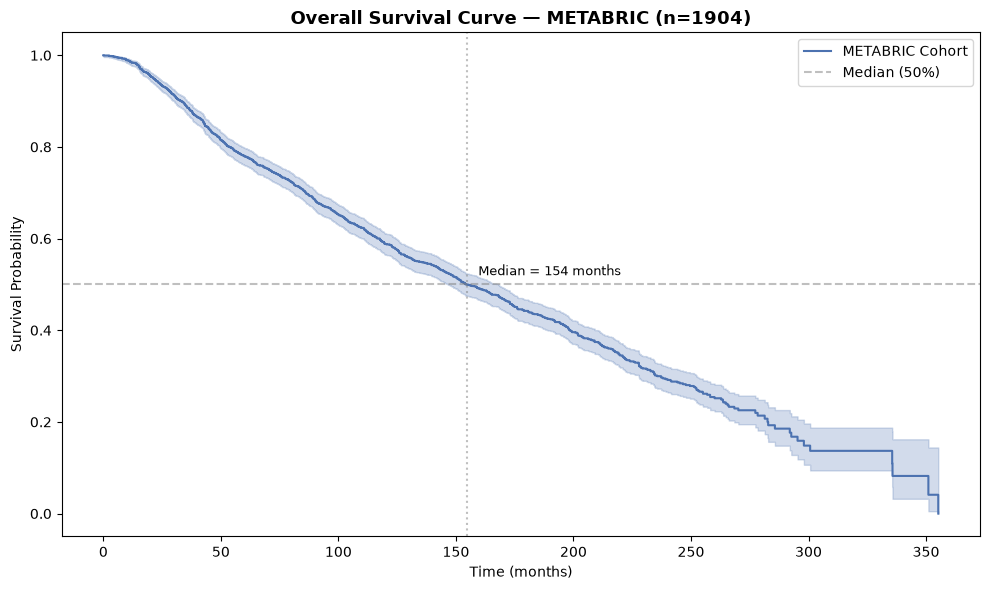

Median survival time: 154 months (~12.9 years)


In [6]:
kmf = KaplanMeierFitter()
kmf.fit(
    durations=df["overall_survival_months"],
    event_observed=df["event"],
    label="METABRIC Cohort"
)

fig, ax = plt.subplots(figsize=(10, 6))
kmf.plot_survival_function(ax=ax, ci_show=True, color="#4C72B0")

median_survival = kmf.median_survival_time_
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Median (50%)")
ax.axvline(median_survival, color="gray", linestyle=":", alpha=0.5)
ax.text(median_survival + 5, 0.52, f"Median = {median_survival:.0f} months", fontsize=9)
ax.set_title("Overall Survival Curve — METABRIC (n=1904)", fontsize=13, fontweight="bold")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/03_km_global.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Median survival time: {median_survival:.0f} months (~{median_survival/12:.1f} years)")

> **Interpretation**:
> - **Median survival: 154 months (~12.9 years)** → 50% of patients
>   survive beyond 12.9 years.
> - **Confidence Interval**: Very narrow (shaded area), reflecting the
>   large sample size (n=1904).
> - **Censoring**: Crosses are visible mainly towards the end of the curve,
>   showing that loss to follow-up happens late in the study.

## 2. KM by ER Status

ER (Estrogen Receptor) status is the most important prognostic
biomarker for breast cancer. ER+ patients are eligible
for targeted hormone therapy.

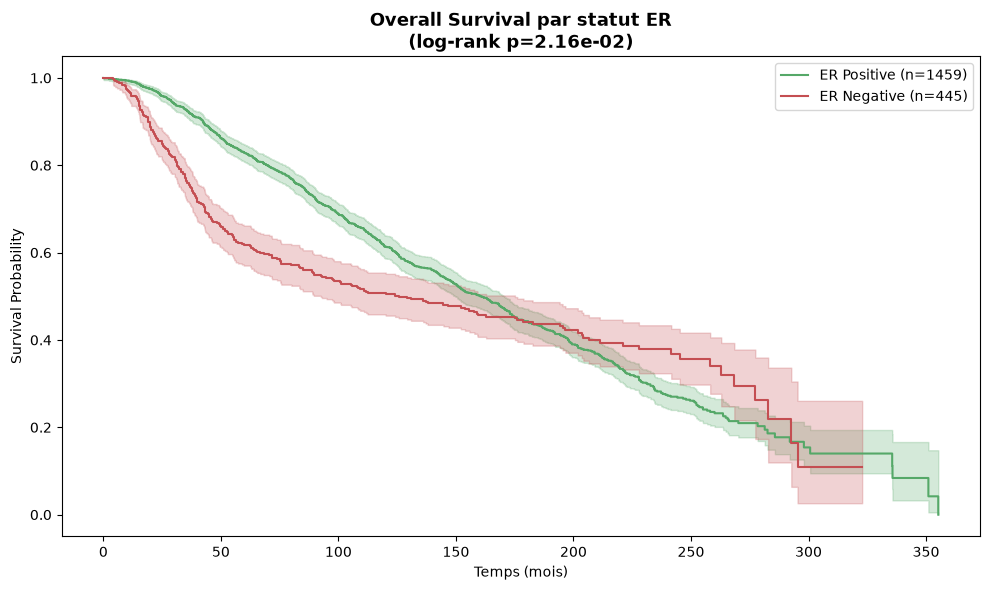

Log-rank p-value : 2.16e-02


In [7]:
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"Positive": "#55A868", "Negative": "#C44E52"}

for group, color in colors.items():
    mask = df_plot["er_status_label"] == group
    kmf.fit(
        durations=df_plot.loc[mask, "overall_survival_months"],
        event_observed=df_plot.loc[mask, "event"],
        label=f"ER {group} (n={mask.sum()})"
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

er_pos = df_plot["er_status_label"] == "Positive"
results_er = logrank_test(
    df_plot.loc[er_pos, "overall_survival_months"],
    df_plot.loc[~er_pos, "overall_survival_months"],
    event_observed_A=df_plot.loc[er_pos, "event"],
    event_observed_B=df_plot.loc[~er_pos, "event"]
)

ax.set_title(f"Overall Survival par statut ER\n(log-rank p={results_er.p_value:.2e})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Temps (mois)")
ax.set_ylabel("Survival Probability")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/03_km_er.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Log-rank p-value : {results_er.p_value:.2e}")

> **Interpretation**:
> - **p=0.02** → Statistically significant difference between ER+ and ER-
> - **Apparent Paradox**: ER+ patients survive better initially, but
>   the curves cross around 150 months (~12 years).
> - **Clinical Reality**: ER- tumors are often more aggressive in the short term,
>   but ER+ tumors have a high risk of late recurrence (dormancy).
> - ⚠️ **Warning for Cox model**: Crossing curves mean
>   the Proportional Hazards (PH) assumption is violated for ER status.

## 3. KM by HER2 Status

HER2 (Human Epidermal growth factor Receptor 2) is overexpressed in
~15-20% of breast cancers. In the METABRIC era,
anti-HER2 targeted therapies (Trastuzumab) were not yet standard.

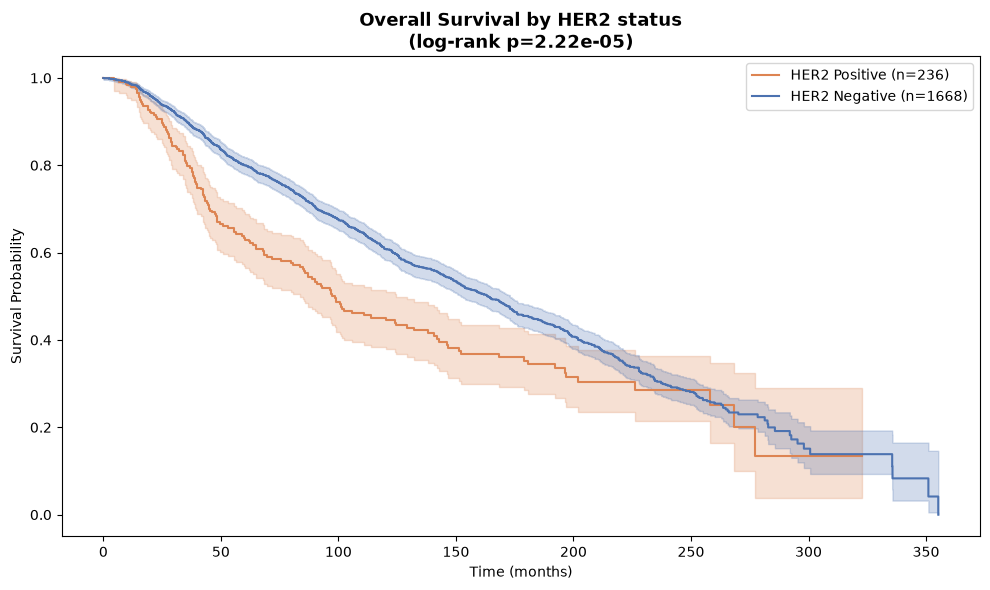

Log-rank p-value: 2.22e-05


In [8]:
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))
colors_her2 = {"Positive": "#DD8452", "Negative": "#4C72B0"}

for group, color in colors_her2.items():
    mask = df_plot["her2_status_label"] == group
    kmf.fit(
        durations=df_plot.loc[mask, "overall_survival_months"],
        event_observed=df_plot.loc[mask, "event"],
        label=f"HER2 {group} (n={mask.sum()})"
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

her2_pos = df_plot["her2_status_label"] == "Positive"
results_her2 = logrank_test(
    df_plot.loc[her2_pos, "overall_survival_months"],
    df_plot.loc[~her2_pos, "overall_survival_months"],
    event_observed_A=df_plot.loc[her2_pos, "event"],
    event_observed_B=df_plot.loc[~her2_pos, "event"]
)

ax.set_title(f"Overall Survival by HER2 status\n(log-rank p={results_her2.p_value:.2e})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/03_km_her2.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Log-rank p-value: {results_her2.p_value:.2e}")

> **Interpretation**:
> - **p=2.22e-05** → Highly significant difference between HER2+ and HER2-
> - The curves **do not cross**: HER2+ consistently has a worse prognosis.
> - This reflects the natural history of HER2+ breast cancer before
>   Trastuzumab: highly aggressive tumors with poor survival.
> - **Cox implication**: Since the curves are parallel, the PH assumption
>   seems valid for HER2 status.

## 4. KM by PR Status

Progesterone Receptor (PR) is biologically dependent
on ER signaling: the majority of PR+ are also ER+.

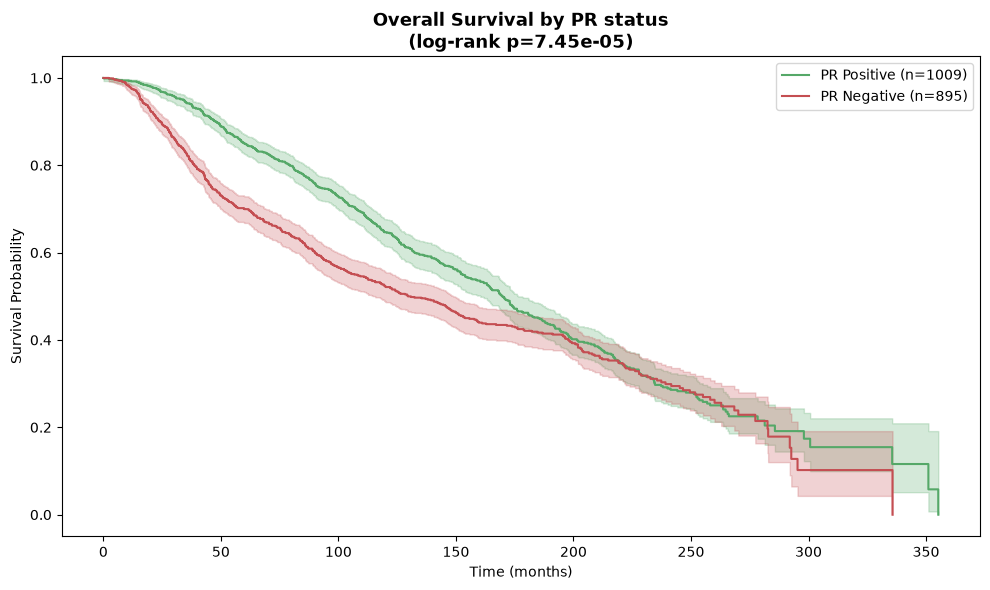

Log-rank p-value: 7.45e-05


In [9]:
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))
colors_pr = {"Positive": "#55A868", "Negative": "#C44E52"}

for group, color in colors_pr.items():
    mask = df_plot["pr_status_label"] == group
    kmf.fit(
        durations=df_plot.loc[mask, "overall_survival_months"],
        event_observed=df_plot.loc[mask, "event"],
        label=f"PR {group} (n={mask.sum()})"
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

pr_pos = df_plot["pr_status_label"] == "Positive"
results_pr = logrank_test(
    df_plot.loc[pr_pos, "overall_survival_months"],
    df_plot.loc[~pr_pos, "overall_survival_months"],
    event_observed_A=df_plot.loc[pr_pos, "event"],
    event_observed_B=df_plot.loc[~pr_pos, "event"]
)

ax.set_title(f"Overall Survival by PR status\n(log-rank p={results_pr.p_value:.2e})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/03_km_pr.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Log-rank p-value: {results_pr.p_value:.2e}")

> **Interpretation**:
> - **p=7.45e-05** → Highly significant difference between PR+ and PR-
> - Similar effect to ER status: PR+ initially has a better prognosis.
> - However, the crossover is less pronounced than for ER, suggesting
>   PR status might be a more robust prognostic indicator over time.

## 5. KM by Histological Grade

The Nottingham grade (1, 2, 3) reflects the degree of tumor differentiation.
Grade 1 = well differentiated (favorable), Grade 3 = poorly differentiated (unfavorable).

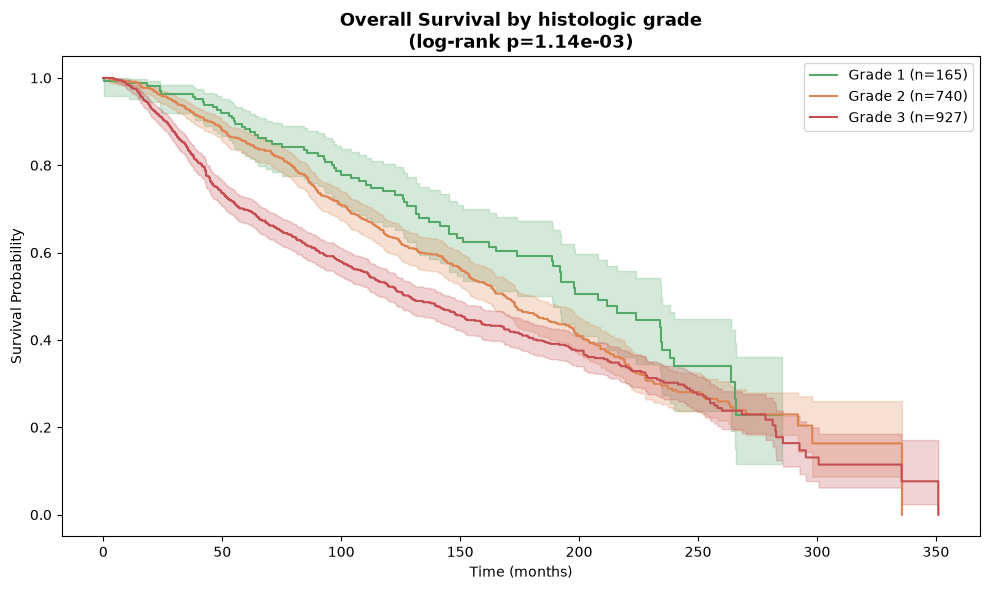

Log-rank p-value: 1.14e-03


In [10]:
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(10, 6))
colors_grade = {1.0: "#55A868", 2.0: "#DD8452", 3.0: "#C44E52"}

for grade, color in colors_grade.items():
    mask = df_plot["neoplasm_histologic_grade_label"] == grade
    kmf.fit(
        durations=df_plot.loc[mask, "overall_survival_months"],
        event_observed=df_plot.loc[mask, "event"],
        label=f"Grade {int(grade)} (n={mask.sum()})"
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

# Multivariate log-rank test (3 groups)
df_grade = df_plot.dropna(subset=["neoplasm_histologic_grade_label"])
results_grade = multivariate_logrank_test(
    df_grade["overall_survival_months"],
    df_grade["neoplasm_histologic_grade_label"],
    event_col=df_grade["event"]
)

ax.set_title(f"Overall Survival by histologic grade\n(log-rank p={results_grade.p_value:.2e})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/03_km_grade.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Log-rank p-value: {results_grade.p_value:.2e}")

> **Interpretation**:
> - **p=1.14e-03** → Significant difference between the three grades
> - Expected clinical gradient: Grade 1 survives better than Grade 2,
>   which survives better than Grade 3.
> - The curves are well separated and do not cross → good candidate
>   for the Cox model.

## 6. KM by Chemotherapy

We analyze the association between chemotherapy and survival. But beware,
in an observational study, treatments are subject to indication bias.

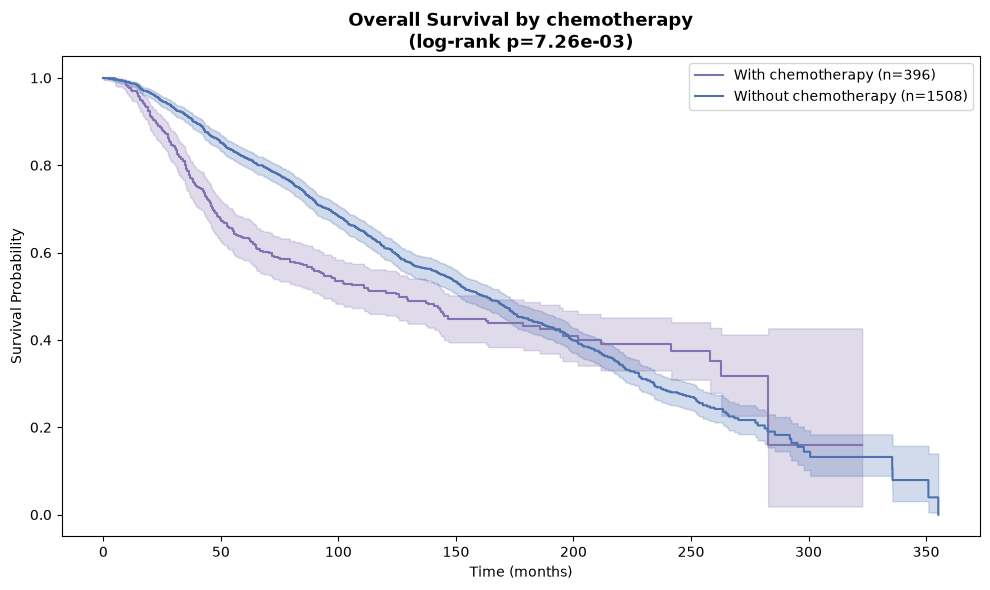

Log-rank p-value: 7.26e-03


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
kmf_chemo    = KaplanMeierFitter()
kmf_nochemo  = KaplanMeierFitter()

mask_chemo   = df_plot["chemotherapy"] == 1
mask_nochemo = df_plot["chemotherapy"] == 0

kmf_chemo.fit(
    durations=df_plot.loc[mask_chemo, "overall_survival_months"],
    event_observed=df_plot.loc[mask_chemo, "event"],
    label=f"With chemotherapy (n={mask_chemo.sum()})"
)
kmf_chemo.plot_survival_function(ax=ax, ci_show=True, color="#8172B2")

kmf_nochemo.fit(
    durations=df_plot.loc[mask_nochemo, "overall_survival_months"],
    event_observed=df_plot.loc[mask_nochemo, "event"],
    label=f"Without chemotherapy (n={mask_nochemo.sum()})"
)
kmf_nochemo.plot_survival_function(ax=ax, ci_show=True, color="#4C72B0")

results_chemo = logrank_test(
    df_plot.loc[mask_chemo, "overall_survival_months"],
    df_plot.loc[mask_nochemo, "overall_survival_months"],
    event_observed_A=df_plot.loc[mask_chemo, "event"],
    event_observed_B=df_plot.loc[mask_nochemo, "event"]
)

ax.set_title(f"Overall Survival by chemotherapy\n(log-rank p={results_chemo.p_value:.2e})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/03_km_chemo.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Log-rank p-value: {results_chemo.p_value:.2e}")

> **Interpretation**:
> - **p=7.26e-03** → Statistically significant difference
> - **Counter-intuitive result**: Patients receiving chemotherapy
>   have a worse survival than those who do not.
> - **Reason (Indication Bias)**: Chemotherapy is prescribed to
>   patients with more severe cancer (Grade 3, large size, positive lymph nodes).
>   The KM curve does not evaluate the *effect* of the treatment, but simply
>   shows that severe patients survive less.
> - Multivariate Cox adjustment is required to disentangle the
>   effect of treatment from the effect of initial severity.

## 7. KM by Hormone Therapy

Hormone therapy (Tamoxifen, aromatase inhibitors) is prescribed to ER+ patients —
who already have a better short-term prognosis.

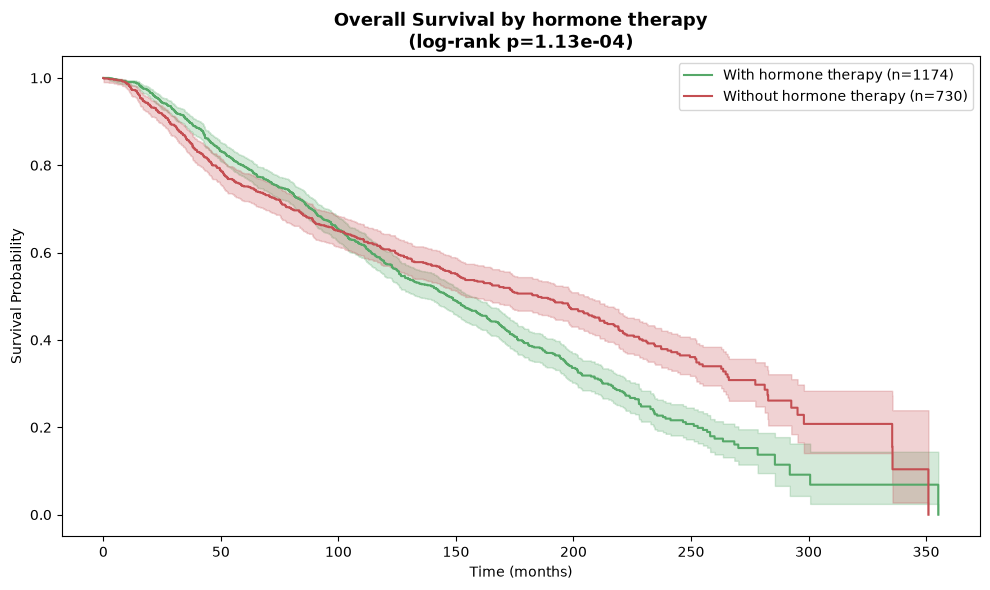

Log-rank p-value: 1.13e-04


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
kmf_hormone   = KaplanMeierFitter()
kmf_nohormone = KaplanMeierFitter()

mask_hormone   = df_plot["hormone_therapy"] == 1
mask_nohormone = df_plot["hormone_therapy"] == 0

kmf_hormone.fit(
    durations=df_plot.loc[mask_hormone, "overall_survival_months"],
    event_observed=df_plot.loc[mask_hormone, "event"],
    label=f"With hormone therapy (n={mask_hormone.sum()})"
)
kmf_hormone.plot_survival_function(ax=ax, ci_show=True, color="#55A868")

kmf_nohormone.fit(
    durations=df_plot.loc[mask_nohormone, "overall_survival_months"],
    event_observed=df_plot.loc[mask_nohormone, "event"],
    label=f"Without hormone therapy (n={mask_nohormone.sum()})"
)
kmf_nohormone.plot_survival_function(ax=ax, ci_show=True, color="#C44E52")

results_hormone = logrank_test(
    df_plot.loc[mask_hormone, "overall_survival_months"],
    df_plot.loc[mask_nohormone, "overall_survival_months"],
    event_observed_A=df_plot.loc[mask_hormone, "event"],
    event_observed_B=df_plot.loc[mask_nohormone, "event"]
)

ax.set_title(f"Overall Survival by hormone therapy\n(log-rank p={results_hormone.p_value:.2e})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/03_km_hormone.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Log-rank p-value: {results_hormone.p_value:.2e}")

> **Interpretation**:
> - **p=1.13e-04** → Highly significant difference
> - Patients receiving hormone therapy survive better.
> - **Reverse Indication Bias**: Hormone therapy is given to ER+ patients
>   (favorable prognosis). Again, a multivariate Cox model is
>   needed to isolate the drug's true effect.

## 8. Summary

| Variable | p-value | Significant | Proportional Hazards | Cox Implication |
|---|---|---|---|---|
| ER Status | 0.02 | ✅ | ⚠️ Curves cross | Model with caution |
| HER2 Status | 2.22e-05 | ✅ | ✅ | Good candidate |
| PR Status | 7.45e-05 | ✅ | ✅ | Good candidate |
| Histological Grade | 3.57e-03 | ✅ | ✅ | Good candidate |
| Chemotherapy | 7.26e-03 | ✅ | ⚠️ Indication bias | Interpret with adjustment |
| Hormone Therapy | 1.13e-04 | ✅ | ⚠️ Indication bias | Interpret with adjustment |

**Conclusions for the Cox model (notebook 04)**:

1. All tested variables are significantly associated with survival
2. HER2, PR, and grade meet the proportional hazards assumption
   → solid candidates for Cox
3. ER status violates this assumption (crossing curves) → to be modeled
   cautiously, potentially adding an interaction with time
4. Chemotherapy and hormone therapy are confounded by indication bias
   → multivariate Cox adjustment is essential to interpret
   their true effect

**Next Step**: `04_cox_model.ipynb` : Univariate then multivariate Cox model